In [30]:
%matplotlib inline

import h5py
import numpy as np
from matplotlib import pyplot as plt
import torch

import fastmri.data.transforms as T

In [31]:
file_path = '../mri_train_images/file1000027.h5'

hf = h5py.File(file_path, 'r')

In [32]:
print('Keys in the HDF5 file:', list(hf.keys()))
print('Attributes in the HDF5 file:', list(hf.attrs))

Keys in the HDF5 file: ['ismrmrd_header', 'kspace', 'reconstruction_esc', 'reconstruction_rss']
Attributes in the HDF5 file: ['acquisition', 'max', 'norm', 'patient_id']


In [33]:
hf.attrs['acquisition']

'CORPDFS_FBK'

In [34]:
# rss = hf['reconstruction_rss'][()]

# slice_id = 15
# singlecoil_kspace_slice = rss[slice_id]
# print(singlecoil_kspace_slice.shape)

# plt.imshow(np.log(np.abs(singlecoil_kspace_slice) + 1e-9), cmap="gray") 
# plt.show()

In [35]:
kspace = hf['kspace'][()]
# mask = hf['mask'][()]
# kspace = kspace * mask
print(kspace.dtype)
print(kspace.shape)

complex64
(34, 640, 368)


(640, 368)


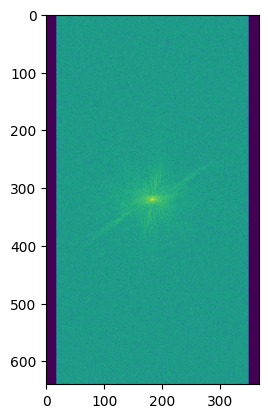

In [36]:
slice_id = 20
singlecoil_kspace_slice = kspace[slice_id]
print(singlecoil_kspace_slice.shape)

plt.imshow(np.log(np.abs(singlecoil_kspace_slice) + 1e-9))
plt.show()

In [37]:
singlecoil_kspace_tensor = T.to_tensor(kspace)
singlecoil_kspace_tensor.shape

torch.Size([34, 640, 368, 2])

In [38]:
singlecoil_sampled_image = fastmri.ifft2c(singlecoil_kspace_tensor)
singlecoil_sampled_image.shape

torch.Size([34, 640, 368, 2])

In [39]:
singlecoil_sampled_image_abs = fastmri.complex_abs(singlecoil_sampled_image)
singlecoil_sampled_image_abs.shape

torch.Size([34, 640, 368])

In [40]:
def show_slices(data, slice_nums, cmap=None):
    fig = plt.figure()
    for i, num in enumerate(slice_nums):
        plt.subplot(1, len(slice_nums), i + 1)
        print(data.shape)
        print(data.dtype)
        plt.imshow(data, cmap=cmap)


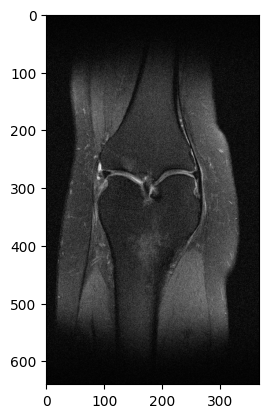

In [41]:
plt.imshow(singlecoil_sampled_image_abs[slice_id].numpy(), cmap="gray") # ?
plt.show()

In [42]:
#Normalize the image
singlecoil_sampled_image_abs = (singlecoil_sampled_image_abs - singlecoil_sampled_image_abs.min()) / (singlecoil_sampled_image_abs.max() - singlecoil_sampled_image_abs.min())

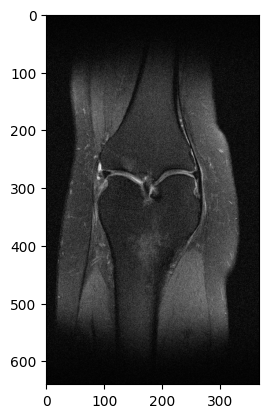

In [43]:
plt.imshow(singlecoil_sampled_image_abs[slice_id].numpy(), cmap="gray")
plt.show()

In [44]:
#Create bounding box for image ((100-150, 200-400)) (X,Y)

#Generate random coordinates inside bounding box to center screw
# x_min = np.random.randint(100, 150)
# y_min = np.random.randint(200, 400)

# #Replace area around location with cross pattern
# cross_size = 9
# thickness = 3
# for t in range(-thickness, thickness + 1):  # Loop to create thickness of the cross
#     for i in range(-cross_size, cross_size + 1):
#         if 0 <= x_min + i < singlecoil_sampled_image_abs.shape[2]:  # Check bounds for x
#             singlecoil_sampled_image_abs[slice_id, y_min + i, x_min + t] = np.random.rand()*0.05  # Set vertical line of cross
#         if 0 <= y_min + i < singlecoil_sampled_image_abs.shape[1]:  # Check bounds for y
#             singlecoil_sampled_image_abs[slice_id, y_min + t, x_min + i] = np.random.rand()*0.05  # Set horizontal line of cross

In [45]:
# Process to simulate metal artifact

# How to simulate this effect for a Gradient Echo vs a Spin Echo sequence

# First part: Simulate spatial shifts due to field inhomogeneity

# Assumptions: Original Image was collected with a Gradient

# Step 1: Map MRI image back to spatial (x,y) coordinates based on resolution

# Step 2: Calculate susceptibility map and overlay on spatial (x,y) grid

# Step 3: Shift all points in x direction according to inhomogeneity

# Step 4: Resample shifted points back onto original (x,y) grid

# Second part: Can you do the same thing in k-space? The shift in image space is spatially dependent

# Third part: Can you simulate intravoxel dephasing, given

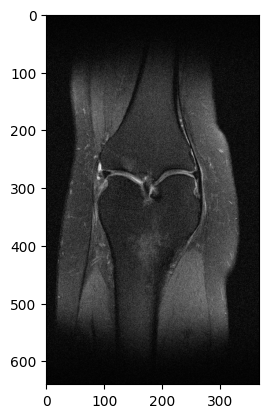

In [46]:
#display modified image
knee_img = singlecoil_sampled_image_abs[slice_id].numpy()
plt.imshow(knee_img, cmap="gray", aspect='equal')
plt.show()

In [156]:
# Define parameters for scanner 

#gamma_over_2pi_Hz_per_G = 4258 # constant 
gradient_x_G_per_mm = 0.08 # estimate from known scanners
knee_img_resolution_mm = 0.5 # get this from the data (0.5mm x 0.5mm x 3.0mm)
knee_img_extent_mm = knee_img_delta_x_mm * knee_img.shape[1]

In [157]:
# Function for spatial shift

def repeat_elements_norm(data, N):
    return [item / N for item in data for _ in range(N)]

print(repeat_elements_norm([1,2], 4))

[0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5]


In [237]:
# function to return a susceptibility map for a cylinder

def cylinder_field_map(a_mm=10.0, chi=3000e-5, theta_rad=np.pi/2, 
                       B0_T=80, resolution_mm=0.5, extent_mm=40.0,
                       x_shift_mm=0, y_shift_mm=0):
    """
    R: Radial distance from cylinder axis
    Phi: Angular position (0 is aligned with the projection of B0)
    a: Cylinder radius
    theta_rad: Angle between B0 and cylinder axis (radians)
    resolution_mm
    """

    n_samples = int(extent_mm / resolution_mm)
    extent_hw = int(extent_mm / 2)

    x = np.linspace(-extent_hw, extent_hw, n_samples)
    y = np.linspace(-extent_hw, extent_hw, n_samples)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt((X-x_shift_mm)**2 + (Y-y_shift_mm)**2)
    Phi = np.arctan2((Y-y_shift_mm), (X-x_shift_mm))
    
    # Initialize field map
    delta_Bz = np.zeros_like(R)
    
    # Mask for inside vs outside
    inside = R <= a_mm
    outside = R > a_mm
    
    # Outside calculation
    delta_Bz[outside] = B0_T * (chi/2) * (a_mm/R[outside])**2 * (np.sin(theta_rad)**2) * np.cos(2*Phi[outside])
    
    # Inside calculation (Uniform field)
    delta_Bz[inside] = B0_T * (chi/6) * (3 * np.cos(theta_rad)**2 - 1)
    
    return delta_Bz

def cylinder_mask(a_mm=10.0, resolution_mm=0.5, extent_mm=40.0,
                       x_shift_mm=0, y_shift_mm=0):
    """
    R: Radial distance from cylinder axis
    Phi: Angular position (0 is aligned with the projection of B0)
    a: Cylinder radius
    theta_rad: Angle between B0 and cylinder axis (radians)
    resolution_mm
    """

    n_samples = int(extent_mm / resolution_mm)
    extent_hw = int(extent_mm / 2)

    x = np.linspace(-extent_hw, extent_hw, n_samples)
    y = np.linspace(-extent_hw, extent_hw, n_samples)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt((X-x_shift_mm)**2 + (Y-y_shift_mm)**2)
    Phi = np.arctan2((Y-y_shift_mm), (X-x_shift_mm))
    
    # Mask for inside vs outside
    outside = R > a_mm
    return outside

def center_crop(arr, crop_h, crop_w):
    # Get current height and width (assumes HWC or HW format)
    h, w = arr.shape[:2]
    
    # Calculate start points
    start_h = h // 2 - (crop_h // 2)
    start_w = w // 2 - (crop_w // 2)
    
    # Return the slice
    # The '...' (Ellipsis) handles extra dimensions like color channels
    return arr[start_h:start_h + crop_h, start_w:start_w + crop_w, ...]

(368, 368) (368, 368)


Text(0.5, 1.0, 'Knee with Cylindrical Implant (Resolution: 0.5 mm)')

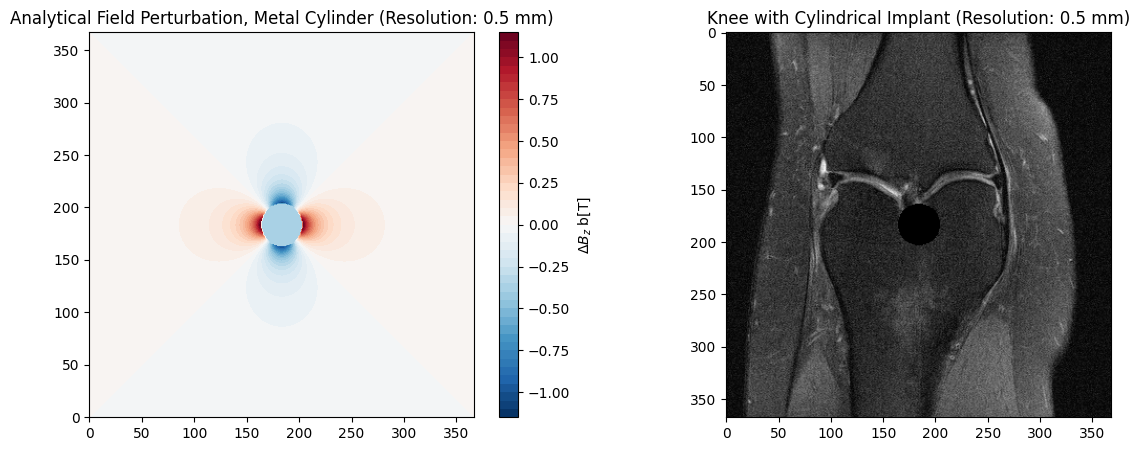

In [238]:
# generate knee image with cylindrical implant
knee_img_cyl = cylinder_mask(extent_mm=knee_img_extent_mm, x_shift_mm = 0) 
knee_img_crop = center_crop(knee_img, knee_img.shape[1], knee_img.shape[1])
knee_img_proc = knee_img_cyl * knee_img_crop

print(knee_img_cyl.shape, knee_img_crop.shape)

# generate susceptibility map
susc_map = cylinder_field_map(extent_mm=knee_img_extent_mm, x_shift_mm = 0, theta_rad=np.pi/2)
susc_map_delta_x_mm = 0.5


# plot susceptibility map
fig, ax = plt.subplots(1,2,figsize=(14,5))
cf = ax[0].contourf(susc_map, levels=50, cmap='RdBu_r')
ax[0].set_title(f"Analytical Field Perturbation, Metal Cylinder (Resolution: {susc_map_delta_x_mm} mm)")
ax[0].set_aspect('equal')
cbar = fig.colorbar(cf,ax=ax[0])
cbar.set_label('$\Delta B_z$ b[T]')

# plot masked knee image
ax[1].imshow(knee_img_proc, cmap='gray')
ax[1].set_title(f'Knee with Cylindrical Implant (Resolution: {knee_img_resolution_mm} mm)')

Text(0.5, 1.0, 'X-Slice of Susceptibility Map, resolution 0.5 mm')

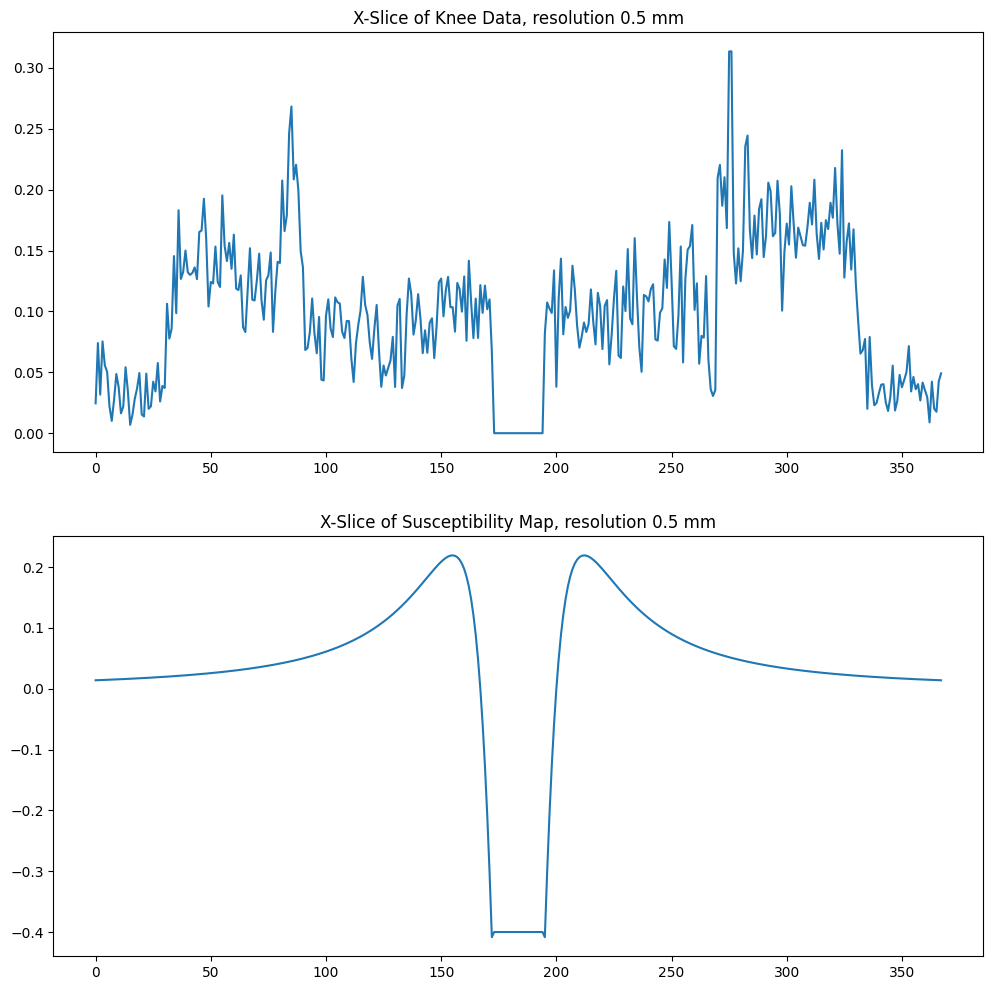

In [239]:
x_slice_img = knee_img_proc[200,:]
x_slice_susc_map = susc_map[200,:]

fig, ax = plt.subplots(2,1,figsize=(12,12))
ax[0].plot(x_slice_img)
ax[0].set_title(f'X-Slice of Knee Data, resolution {img_delta_x_mm} mm')

ax[1].plot(x_slice_susc_map)
ax[1].set_title(f'X-Slice of Susceptibility Map, resolution {susc_map_delta_x_mm} mm')

In [240]:
# 1d version of spins shifting based on susceptibility
def x_shift(x_slice, y_slice, x_slice_res_mm=0.5, cylinder_x_shift_mm=0, upsample_factor=1):

    # final x slice
    x_slice_shift = np.zeros(x_slice.shape)

    # upsample the observed x values
    x_slice_up = repeat_elements_norm(x_slice, upsample_factor)
    x_slice_up_res_mm = x_slice_res_mm / upsample_factor # new resolution

    # create new susceptibility map at the desired resolution
    x_slice_extent_mm = x_slice_res_mm * x_slice.shape[0]
    susc_map_up = cylinder_field_map(resolution_mm=x_slice_up_res_mm,
                                     extent_mm=x_slice_extent_mm,
                                     x_shift_mm=cylinder_x_shift_mm)

    x_susc_map = susc_map_up[y_slice,:]
    
    # loop through x values and shift according to susceptibility map
    for i in range(len(x_slice_up)):
        x_shift = x_susc_map[i] / (gradient_x_G_per_mm * x_slice_up_res_mm)
        x_prime = int(np.round(i + x_shift))

        if x_prime >= 0 and x_prime < x_slice.shape[0]:
            x_slice_shift[x_prime] += x_slice_up[i]

    return x_slice_shift

In [241]:
# read in an x-slice of the original image, and plot next to the scaled susceptibility map

new_x_slice_img = x_shift(x_slice_img, y_slice=200, x_slice_res_mm=0.5)

Text(0.5, 1.0, 'X-Slice of Knee Data with Metal Artifacts, resolution 0.5 mm')

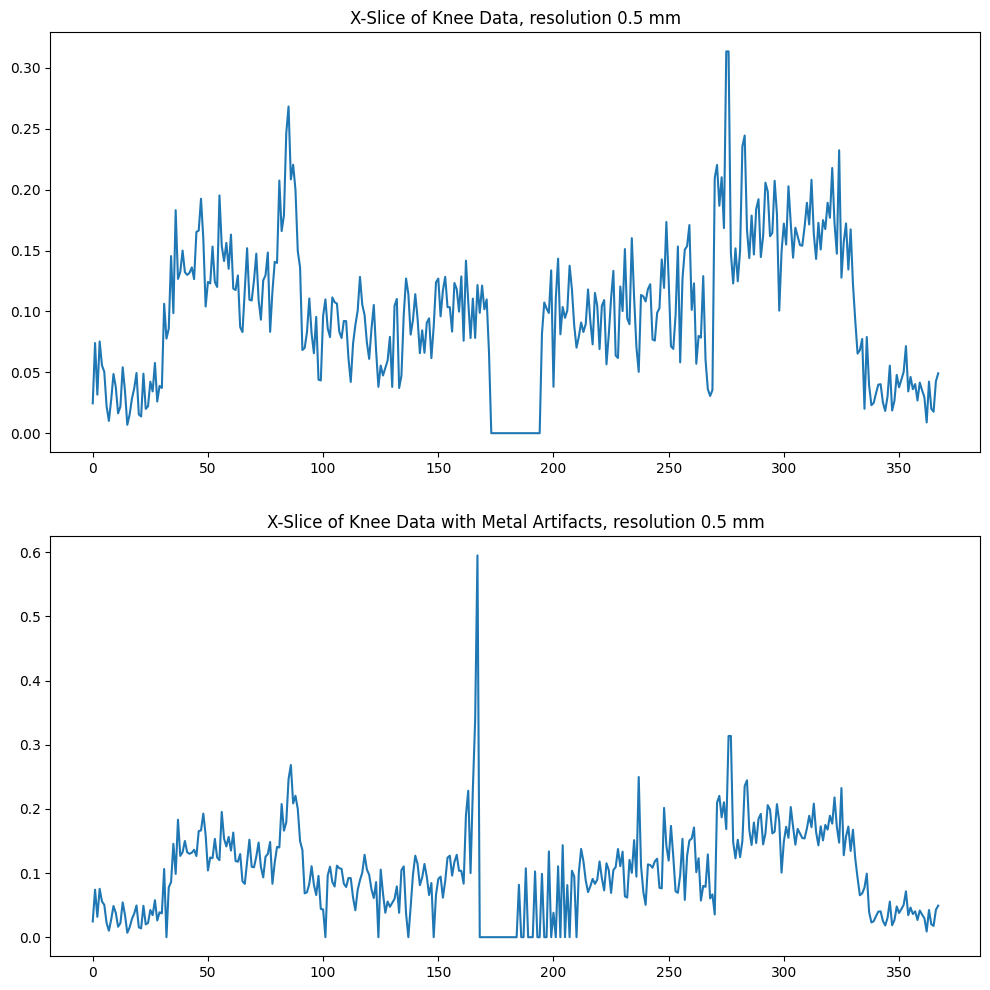

In [242]:
fig, ax = plt.subplots(2,1,figsize=(12,12))
ax[0].plot(x_slice_img)
ax[0].set_title(f'X-Slice of Knee Data, resolution {img_delta_x_mm} mm')

ax[1].plot(new_x_slice_img)
ax[1].set_title(f'X-Slice of Knee Data with Metal Artifacts, resolution {susc_map_delta_x_mm} mm')

In [243]:
# call 1d version as subroutine on image
def full_susceptibility_shift(img, x_slice_res_mm=0.5, cylinder_x_shift_mm=0, upsample_factor=1):

    final_img = np.zeros(img.shape)

    for i in range(img.shape[0]):
        curr_x_slice = img[i,:]
        x_slice_shift = x_shift(curr_x_slice,i)
        final_img[i,:] = x_slice_shift

    return final_img

Text(0.5, 1.0, 'Knee with Cylindrical Implant (Resolution: 0.5 mm)')

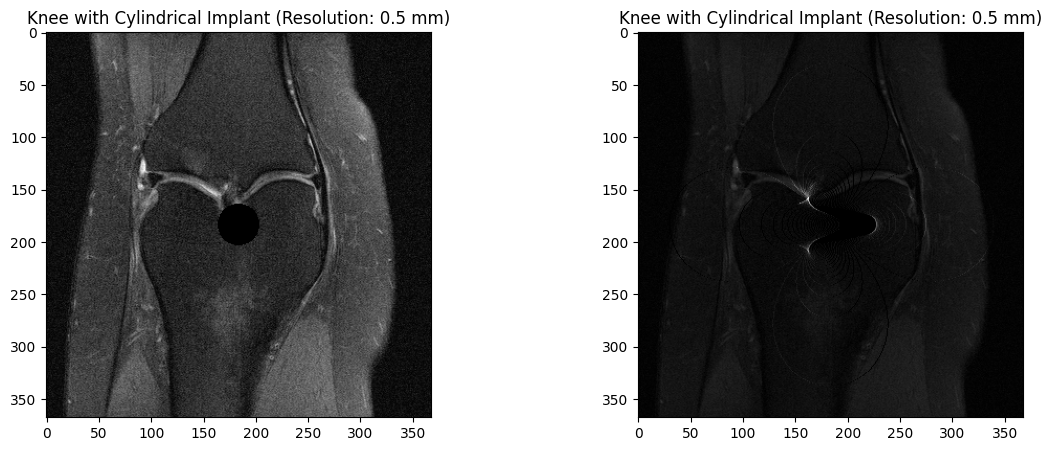

In [244]:
knee_img_with_artifacts = full_susceptibility_shift(knee_img_proc, upsample_factor=5)

fig, ax = plt.subplots(1,2,figsize=(14,5))

# plot original knee image
ax[0].imshow(knee_img_proc, cmap='gray')
ax[0].set_title(f'Knee with Cylindrical Implant (Resolution: {knee_img_resolution_mm} mm)')

# plot masked knee image
ax[1].imshow(knee_img_with_artifacts, cmap='gray')
ax[1].set_title(f'Knee with Cylindrical Implant (Resolution: {knee_img_resolution_mm} mm)')